# 02 - Exploratory Data Analysis

Understanding the distribution of target variables, material class breakdown, 
and missing values in ML-HydPARK.

## Goals
- Distribution of target variables: `Temperature_oC` and `Hydrogen_Weight_Percent`
- Material class breakdown
- Missing values
- Correlations between features

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading the dataset
df = pd.read_csv('../data/raw/ML-HYDPARK_v0.0.5.csv')
df.shape

(772, 13)

In [3]:
df.head()

,Unnamed: 0,index,Material_Class,Composition_Formula,Hydrogen_Weight_Percent,Heat_of_Formation_kJperMolH2,Temperature_oC,Pressure_Atmospheres_Absolute,Entropy_of_Formation_JperMolH2perK,Equilibrium_Pressure_25C,LnEquilibrium_Pressure_25C,HtoM,Reference
0,0,0,A2B,Th2Al,0.8,130.0,500.0,0.001,110.711134,1.016736e-17,-39.127349,1.309571,NaN
1,1,1,A2B,Ti2Cu,2.2,130.0,500.0,0.120,150.515102,1.220083e-15,-34.339857,1.184850,NaN
2,2,2,A2B,Zr2Cu,1.3,144.0,600.0,0.003,116.621978,7.297612e-20,-44.064155,1.071443,NaN
3,3,3,A2B,Zr2Ni,1.3,183.0,604.0,0.003,160.332084,2.058957e-24,-54.539843,1.050307,NaN
4,4,4,A2B,Mg2Ni,3.6,64.5,299.0,3.200,122.403296,1.240158e-05,-11.297687,1.325126,NaN


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 772 entries, 0 to 771
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Unnamed: 0                          772 non-null    int64  
 1   index                               772 non-null    int64  
 2   Material_Class                      747 non-null    object 
 3   Composition_Formula                 772 non-null    object 
 4   Hydrogen_Weight_Percent             741 non-null    float64
 5   Heat_of_Formation_kJperMolH2        772 non-null    float64
 6   Temperature_oC                      412 non-null    float64
 7   Pressure_Atmospheres_Absolute       403 non-null    float64
 8   Entropy_of_Formation_JperMolH2perK  772 non-null    float64
 9   Equilibrium_Pressure_25C            770 non-null    float64
 10  LnEquilibrium_Pressure_25C          772 non-null    float64
 11  HtoM                                741 non-n

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,772.0,385.500000,223.001495,0.000000e+00,192.750000,385.500000,578.250000,771.000000
index,772.0,175.268135,112.167211,0.000000e+00,76.750000,173.000000,269.250000,397.000000
Hydrogen_Weight_Percent,741.0,1.582423,0.722931,0.000000e+00,1.200000,1.508332,1.800000,6.200000
Heat_of_Formation_kJperMolH2,772.0,34.313845,19.030924,1.030000e+00,23.695000,29.740000,39.000000,219.000000
Temperature_oC,412.0,90.324029,127.646810,-7.800000e+01,22.000000,30.000000,100.000000,800.000000
Pressure_Atmospheres_Absolute,403.0,12.870589,189.239151,1.000000e-04,0.300000,1.200000,4.000000,3800.000000
Entropy_of_Formation_JperMolH2perK,772.0,106.971091,22.523260,-5.178960e+00,96.409294,107.800000,117.518696,260.184403
Equilibrium_Pressure_25C,770.0,128.558815,1464.815705,3.911145e-29,0.103723,1.172564,15.342577,37390.128730
LnEquilibrium_Pressure_25C,772.0,-0.975250,6.677712,-6.541114e+01,-2.281708,0.150750,2.713776,10.529162
HtoM,741.0,0.961384,0.295541,0.000000e+00,0.807748,0.960000,1.098067,2.354015


### Sign Convention Note

`Heat_of_Formation_kJperMolH2` and `Entropy_of_Formation_JperMolH2perK` are stored as **positive absolute values**, despite the thermodynamic convention that ΔH and ΔS of hydride formation (H₂ absorption) are negative. The reaction is exothermic and reduces entropy as gas becomes solid.

This can be verified via the van 't Hoff equation at T = 25°C (298.15 K):

$$\ln(P_{eq}) = \frac{\Delta H}{RT} - \frac{\Delta S}{R}$$

Using row 0 (Th₂Al) with the stored positive values gives ln(P) = +39.13, but `LnEquilibrium_Pressure_25C` = −39.13. Negating both ΔH and ΔS recovers the correct result. The dataset therefore stores the **desorption** thermodynamic quantities (endothermic direction, positive sign) under column names labelled "Formation". This is a known convention in parts of the hydride literature and must be accounted for when interpreting model outputs.

## Dataset Overview

- 772 entries, 13 columns
- `Temperature_oC`: main target, 412 non-null values (47% NaN)
- `Hydrogen_Weight_Percent`: secondary target, 741 non-null values (4% NaN)
- `Material_Class`: 747 non-null values, categorical feature
- `Reference`: 373 non-null values, feature to drop
- `Unnamed: 0` and `index`: duplicates, features that do not add any value and will be dropped

The median value for `Temperature_oC` is 30°C, whilst the mean is 90°C. While the dataset is centered on the window of interest of near-room temperature, the distribution appears to be positively skewed.
The minimum value of `Temperature_oC` is -78°C, which is likely a legitimate experimental condition. The specific material and thermodynamic system behind this entry will be investigated.

In [6]:
# Dropping 'Unnamed: 0', 'index' and 'Reference' columns
cols_to_drop = ['Unnamed: 0', 'index', 'Reference']
df = df.drop(columns = cols_to_drop)
df.shape



(772, 10)

In [7]:
df.head()

,Material_Class,Composition_Formula,Hydrogen_Weight_Percent,Heat_of_Formation_kJperMolH2,Temperature_oC,Pressure_Atmospheres_Absolute,Entropy_of_Formation_JperMolH2perK,Equilibrium_Pressure_25C,LnEquilibrium_Pressure_25C,HtoM
0,A2B,Th2Al,0.8,130.0,500.0,0.001,110.711134,1.016736e-17,-39.127349,1.309571
1,A2B,Ti2Cu,2.2,130.0,500.0,0.120,150.515102,1.220083e-15,-34.339857,1.184850
2,A2B,Zr2Cu,1.3,144.0,600.0,0.003,116.621978,7.297612e-20,-44.064155,1.071443
3,A2B,Zr2Ni,1.3,183.0,604.0,0.003,160.332084,2.058957e-24,-54.539843,1.050307
4,A2B,Mg2Ni,3.6,64.5,299.0,3.200,122.403296,1.240158e-05,-11.297687,1.325126


In [8]:
df[['LnEquilibrium_Pressure_25C', 'Equilibrium_Pressure_25C']].head(10)

,LnEquilibrium_Pressure_25C,Equilibrium_Pressure_25C
0,-39.127349,1.016736e-17
1,-34.339857,1.220083e-15
2,-44.064155,7.297612e-20
3,-54.539843,2.058957e-24
4,-11.297687,1.240158e-05
5,-11.969699,6.333240e-06
6,-11.978132,6.280057e-06
7,-10.688950,2.279544e-05
8,-10.054265,4.300196e-05
9,-9.974222,4.658545e-05


In [9]:
# Dropping 'Equilibrium_Pressure_25C' as 'LnEquilibrium_Pressure_25C' is directly calculated from it
# 'LnEquilibrium_Pressure_25C' has values more interpretable for the human brain
df = df.drop(columns = ['Equilibrium_Pressure_25C'], axis = 1)
df.shape

(772, 9)

In [10]:
# Exploration of missing values across the dataframe
df.isna().sum()

Material_Class                         25
Composition_Formula                     0
Hydrogen_Weight_Percent                31
Heat_of_Formation_kJperMolH2            0
Temperature_oC                        360
Pressure_Atmospheres_Absolute         369
Entropy_of_Formation_JperMolH2perK      0
LnEquilibrium_Pressure_25C              0
HtoM                                   31
dtype: int64

In [11]:
# Checking whether the NaNs in 'Temperature_oC' are also missing in 'Pressure_Atmospheres_Absolute'
df[df['Temperature_oC'].isna() & df['Pressure_Atmospheres_Absolute'].isna()].shape

(360, 9)

All 360 NaNs in `Temperature_oC` are also missing in `Pressure_Atmospheres_Absolute`.

Key considerations:
- Exploring `Pressure_Atmospheres_Absolute` it would seem that it refers to the plateau pressure of the absorption/desorption process and not an experimental condition (usually solid state hydrogen systems are at atmospheric pressure).
- `Temperature_oC` only consists of 412 values that can be used.

Routes to follow:
- Split the analysis into two.
- Dataset A: 741 rows, target variable changes to `Hydrogen_Weight_Percent`. More data but secondary target.
- Dataset B: 412 rows, target variable remains `Temperature_oC`. Less data, but primary target variable retained.

### Target variables distribution

We examine the distribution of both target variables: `Temperature_oC` (412 non-null values) and `Hydrogen_Weight_Percent` (741 non-null values) using histograms with KDE overlay and boxplots.

The goal is to identify skewness, outliers, and any features of the distribution that will inform modelling decisions for Dataset A and Dataset B.

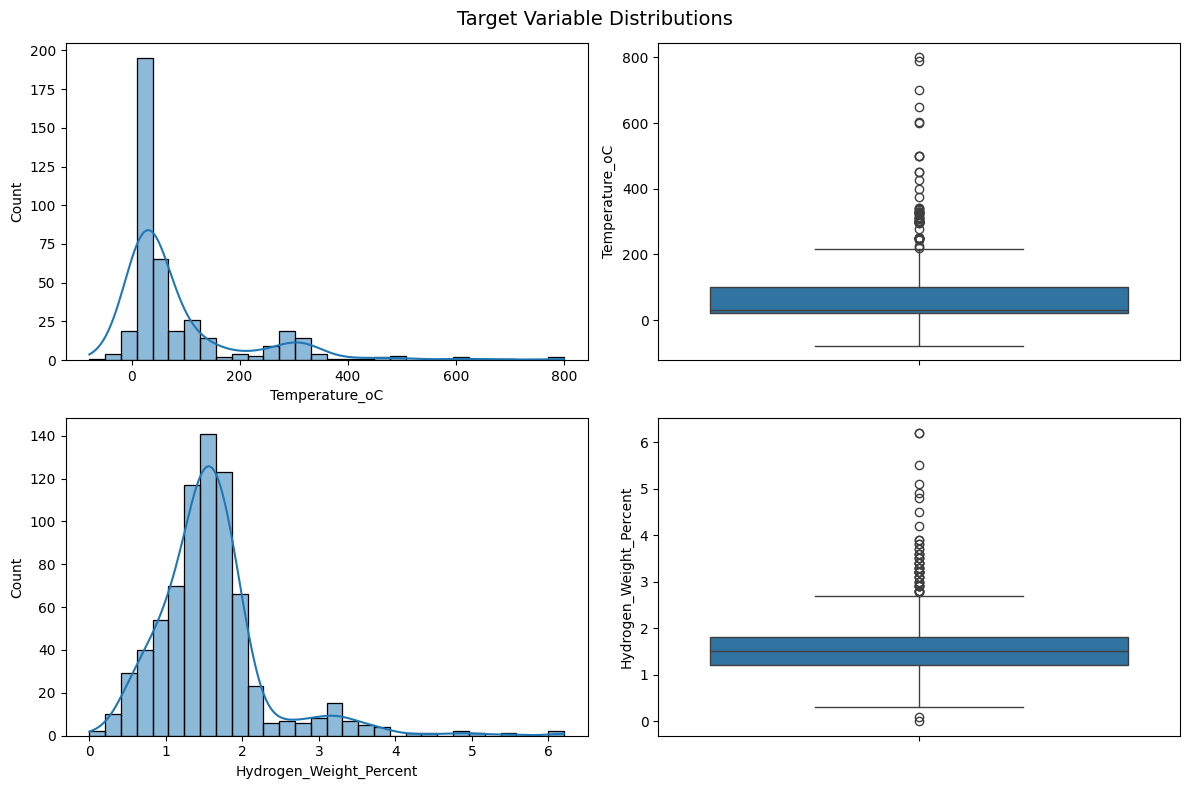

In [12]:
# Dropping the NaNs in both target variables
temp = df['Temperature_oC'].dropna()
hwp = df['Hydrogen_Weight_Percent'].dropna()

# Plotting the histogram+KDE and boxplot for each target variable
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Target Variable Distributions', fontsize=14)
sns.histplot(temp, bins=30, kde=True, ax=axes[0, 0])
sns.boxplot(y=temp, ax=axes[0, 1])
sns.histplot(hwp, bins=30, kde=True, ax=axes[1, 0])
sns.boxplot(y=hwp, ax=axes[1, 1])
plt.tight_layout()
plt.savefig('../results/target_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### Observations

Both distributions are right-skewed, more pronounced for `Temperature_oC` (mean 90°C, median 30°C) than for `Hydrogen_Weight_Percent` (mean 1.58%, median ~1.51%).

The boxplots flag a large number of points as outliers, but this is a mechanical artefact of the IQR rule, which assumes roughly symmetric data. On a right-skewed distribution it will always flag the tail: these are not erroneous values and will not be treated as such.

More interestingly, the `Temperature_oC` histogram shows two distinct humps: one centred around 25–30°C and a second around 200–300°C. This strongly suggests the dataset is a mixture of distinct material populations with fundamentally different thermodynamic profiles, rather than a single homogeneous distribution. The same hypothesis applies to `Hydrogen_Weight_Percent`. This will be investigated in the material class breakdown section.